In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

model = joblib.load("../models/improved_logistic_regression_model.pkl")

elo_table = pd.read_csv("../data/processed/latest_elo_ratings.csv")

latest_elo = dict(
    zip(elo_table["team"], elo_table["elo_rating"])
)

def predict_match(home_team, away_team, neutral=True):
    home_elo = latest_elo.get(home_team, 1500)
    away_elo = latest_elo.get(away_team, 1500)

    elo_difference = home_elo - away_elo
    home_advantage = 0 if neutral else 1

    X_match = pd.DataFrame([
        {
            "elo_difference": elo_difference,
            "home_advantage": home_advantage,
        }
    ])

    probabilities = model.predict_proba(X_match)[0]

    return dict(zip(model.classes_, probabilities))


def simulate_match(home_team, away_team, neutral=True):
    probabilities = predict_match(home_team, away_team, neutral)

    outcomes = list(probabilities.keys())
    probs = list(probabilities.values())

    return np.random.choice(outcomes, p=probs)


def simulate_knockout_match(home_team, away_team):
    probabilities = predict_match(home_team, away_team, neutral=True)

    home_prob = probabilities.get("home_win", 0)
    away_prob = probabilities.get("away_win", 0)

    total = home_prob + away_prob

    if total == 0:
        return np.random.choice([home_team, away_team])

    home_advances_prob = home_prob / total

    return np.random.choice(
        [home_team, away_team],
        p=[home_advances_prob, 1 - home_advances_prob]
    )

In [2]:
world_cup_groups = {
    "Group A": ["Qatar", "Ecuador", "Senegal", "Netherlands"],
    "Group B": ["England", "Iran", "United States", "Wales"],
    "Group C": ["Argentina", "Saudi Arabia", "Mexico", "Poland"],
    "Group D": ["France", "Australia", "Denmark", "Tunisia"],
    "Group E": ["Spain", "Costa Rica", "Germany", "Japan"],
    "Group F": ["Belgium", "Canada", "Morocco", "Croatia"],
    "Group G": ["Brazil", "Serbia", "Switzerland", "Cameroon"],
    "Group H": ["Portugal", "Ghana", "Uruguay", "South Korea"],
}

In [3]:
def generate_group_fixtures(teams):
    fixtures = []

    for i in range(len(teams)):
        for j in range(i + 1, len(teams)):
            fixtures.append((teams[i], teams[j]))

    return fixtures


def get_group_points(result):
    if result == "home_win":
        return 3, 0

    if result == "away_win":
        return 0, 3

    return 1, 1


def simulate_group(teams):
    standings = {}

    for team in teams:
        standings[team] = {
            "points": 0,
            "wins": 0,
            "draws": 0,
            "losses": 0,
        }

    fixtures = generate_group_fixtures(teams)

    for home_team, away_team in fixtures:
        result = predict_match(home_team, away_team, neutral=True)

        outcomes = list(result.keys())
        probs = list(result.values())

        match_result = np.random.choice(outcomes, p=probs)

        home_points, away_points = get_group_points(match_result)

        standings[home_team]["points"] += home_points
        standings[away_team]["points"] += away_points

        if match_result == "home_win":
            standings[home_team]["wins"] += 1
            standings[away_team]["losses"] += 1

        elif match_result == "away_win":
            standings[away_team]["wins"] += 1
            standings[home_team]["losses"] += 1

        else:
            standings[home_team]["draws"] += 1
            standings[away_team]["draws"] += 1

    ranked_teams = sorted(
        standings.items(),
        key=lambda item: (
            item[1]["points"],
            item[1]["wins"],
            np.random.random()
        ),
        reverse=True
    )

    return ranked_teams

In [5]:
def simulate_world_cup_once(groups):
    group_results = {}

    for group_name, teams in groups.items():
        group_results[group_name] = simulate_group(teams)

    a1 = group_results["Group A"][0][0]
    a2 = group_results["Group A"][1][0]

    b1 = group_results["Group B"][0][0]
    b2 = group_results["Group B"][1][0]

    c1 = group_results["Group C"][0][0]
    c2 = group_results["Group C"][1][0]

    d1 = group_results["Group D"][0][0]
    d2 = group_results["Group D"][1][0]

    e1 = group_results["Group E"][0][0]
    e2 = group_results["Group E"][1][0]

    f1 = group_results["Group F"][0][0]
    f2 = group_results["Group F"][1][0]

    g1 = group_results["Group G"][0][0]
    g2 = group_results["Group G"][1][0]

    h1 = group_results["Group H"][0][0]
    h2 = group_results["Group H"][1][0]

    round_of_16 = [
        (a1, b2),
        (c1, d2),
        (e1, f2),
        (g1, h2),
        (b1, a2),
        (d1, c2),
        (f1, e2),
        (h1, g2),
    ]

    quarterfinalists = []

    for team_1, team_2 in round_of_16:
        winner = simulate_knockout_match(team_1, team_2)
        quarterfinalists.append(winner)

    quarterfinals = [
        (quarterfinalists[0], quarterfinalists[1]),
        (quarterfinalists[2], quarterfinalists[3]),
        (quarterfinalists[4], quarterfinalists[5]),
        (quarterfinalists[6], quarterfinalists[7]),
    ]

    semifinalists = []

    for team_1, team_2 in quarterfinals:
        winner = simulate_knockout_match(team_1, team_2)
        semifinalists.append(winner)

    semifinals = [
        (semifinalists[0], semifinalists[1]),
        (semifinalists[2], semifinalists[3]),
    ]

    finalists = []

    for team_1, team_2 in semifinals:
        winner = simulate_knockout_match(team_1, team_2)
        finalists.append(winner)

    champion = simulate_knockout_match(finalists[0], finalists[1])

    return {
        "group_results": group_results,
        "round_of_16": [team for matchup in round_of_16 for team in matchup],
        "quarterfinalists": quarterfinalists,
        "semifinalists": semifinalists,
        "finalists": finalists,
        "champion": champion,
    }

In [7]:
num_simulations = 10000

team_results = {}

for group_teams in world_cup_groups.values():
    for team in group_teams:
        team_results[team] = {
            "group_advancement": 0,
            "quarterfinal": 0,
            "semifinal": 0,
            "final": 0,
            "champion": 0,
        }


for _ in range(num_simulations):
    result = simulate_world_cup_once(world_cup_groups)

    for group_name, group_result in result["group_results"].items():
        advanced_teams = [
            group_result[0][0],
            group_result[1][0],
        ]

        for team in advanced_teams:
            team_results[team]["group_advancement"] += 1

    for team in result["quarterfinalists"]:
        team_results[team]["quarterfinal"] += 1

    for team in result["semifinalists"]:
        team_results[team]["semifinal"] += 1

    for team in result["finalists"]:
        team_results[team]["final"] += 1

    team_results[result["champion"]]["champion"] += 1


simulation_results = pd.DataFrame.from_dict(
    team_results,
    orient="index"
)

simulation_results = simulation_results / num_simulations

simulation_results = simulation_results.sort_values(
    "champion",
    ascending=False
)

simulation_results

,group_advancement,quarterfinal,semifinal,final,champion
Argentina,0.9093,0.6537,0.4383,0.3011,0.1877
France,0.9202,0.6396,0.4324,0.3099,0.1786
Spain,0.8411,0.6480,0.4859,0.2628,0.1670
England,0.8406,0.5661,0.2911,0.1790,0.0838
Netherlands,0.8060,0.5376,0.2802,0.1641,0.0812
Brazil,0.8870,0.6237,0.2967,0.1371,0.0720
Germany,0.5990,0.3582,0.2199,0.0940,0.0420
Mexico,0.7327,0.3624,0.1876,0.1004,0.0402
Portugal,0.8448,0.5277,0.2414,0.0959,0.0374
Japan,0.4385,0.2280,0.1309,0.0454,0.0162


In [8]:
simulation_results.to_csv(
    "../data/processed/world_cup_simulation_results.csv"
)

simulation_results.head(10)

,group_advancement,quarterfinal,semifinal,final,champion
Argentina,0.9093,0.6537,0.4383,0.3011,0.1877
France,0.9202,0.6396,0.4324,0.3099,0.1786
Spain,0.8411,0.6480,0.4859,0.2628,0.1670
England,0.8406,0.5661,0.2911,0.1790,0.0838
Netherlands,0.8060,0.5376,0.2802,0.1641,0.0812
Brazil,0.8870,0.6237,0.2967,0.1371,0.0720
Germany,0.5990,0.3582,0.2199,0.0940,0.0420
Mexico,0.7327,0.3624,0.1876,0.1004,0.0402
Portugal,0.8448,0.5277,0.2414,0.0959,0.0374
Japan,0.4385,0.2280,0.1309,0.0454,0.0162


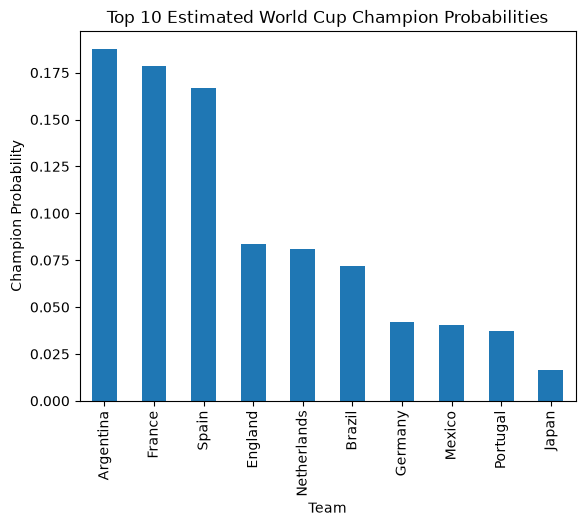

In [9]:
top_champions = simulation_results["champion"].head(10)

top_champions.plot(kind="bar")

plt.title("Top 10 Estimated World Cup Champion Probabilities")
plt.ylabel("Champion Probability")
plt.xlabel("Team")

plt.show()

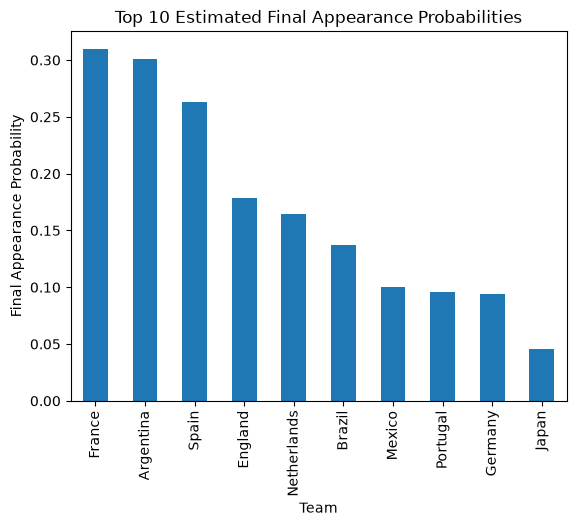

In [10]:
top_finalists = simulation_results["final"].sort_values(
    ascending=False
).head(10)

top_finalists.plot(kind="bar")

plt.title("Top 10 Estimated Final Appearance Probabilities")
plt.ylabel("Final Appearance Probability")
plt.xlabel("Team")

plt.show()

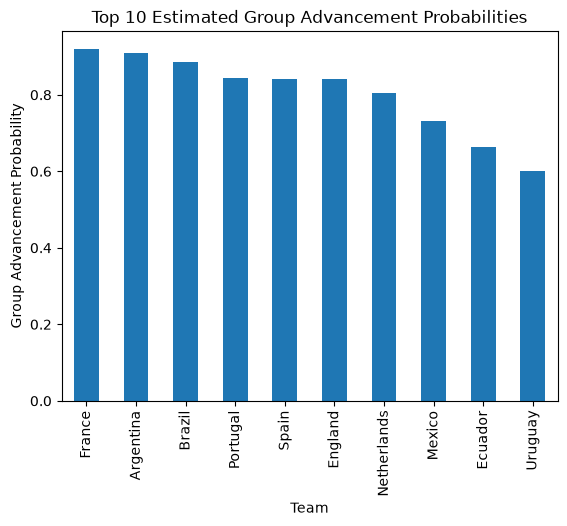

In [11]:
top_group_advancers = simulation_results["group_advancement"].sort_values(
    ascending=False
).head(10)

top_group_advancers.plot(kind="bar")

plt.title("Top 10 Estimated Group Advancement Probabilities")
plt.ylabel("Group Advancement Probability")
plt.xlabel("Team")

plt.show()